In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,  roc_auc_score
import xgboost as xgb



from sklearn.impute import KNNImputer



import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix


from imblearn.under_sampling import TomekLinks
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression


from sklearn.cluster import KMeans




In [ ]:


data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/iseng/Stroke imbalanced/dataset.csv')

data.head(20)




,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
5,32257,Female,47.0,0,0,Yes,Private,Urban,210.95,50.1,NaN,0
6,52800,Female,52.0,0,0,Yes,Private,Urban,77.59,17.7,formerly smoked,0
7,41413,Female,75.0,0,1,Yes,Self-employed,Rural,243.53,27.0,never smoked,0
8,15266,Female,32.0,0,0,Yes,Private,Rural,77.67,32.3,smokes,0
9,28674,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0


#Exploratory Data Analysis

Text(0.5, 1.0, 'Target distribution')

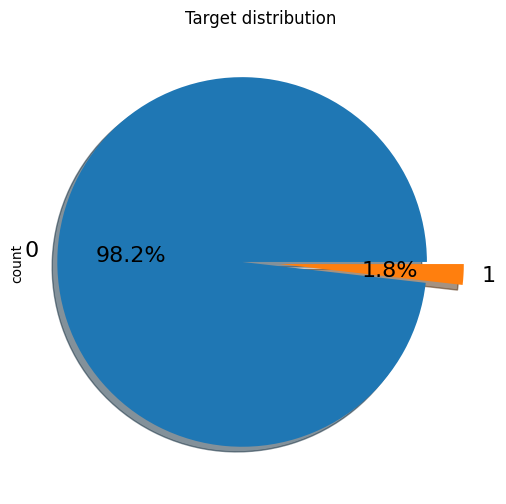

In [ ]:

plt.figure(figsize=(6,6))

# Pie plot
data['stroke'].value_counts().plot.pie(explode=[0.1,0.1], autopct='%1.1f%%', shadow=True, textprops={'fontsize':16}).set_title("Target distribution")
# no imbalance class

In [ ]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (data.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
cat_col = []
num_col = []

for i in data.columns:
    dtype_str = str(data[i].dtype)
    if 'int' in dtype_str or 'float' in dtype_str:
        num_col.append(i)
    else:
        cat_col.append(i)

print("Numerik:", num_col)
print("Kategorikal:", cat_col)


Numerik: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Kategorikal: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


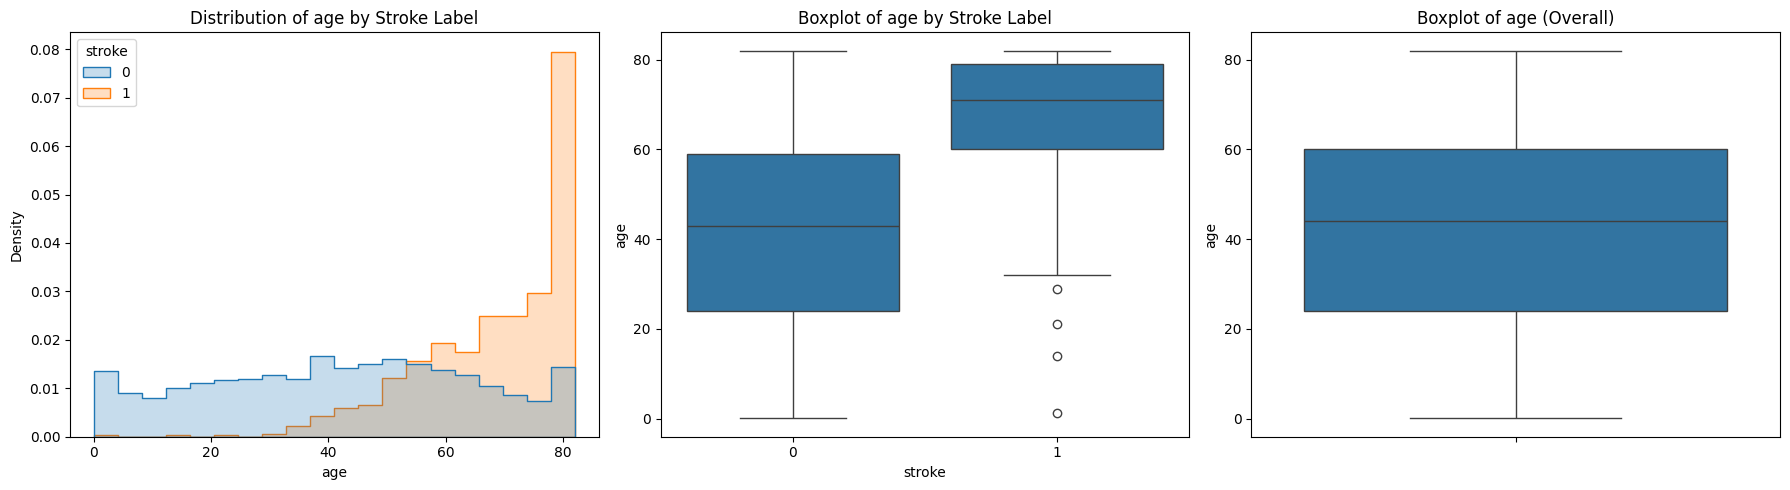

Distribution for age:
  Stroke = 0: Skewness = -0.0869, Kurtosis = -0.9934
  Stroke = 1: Skewness = -1.1215, Kurtosis = 1.3529
-----------------------------------------


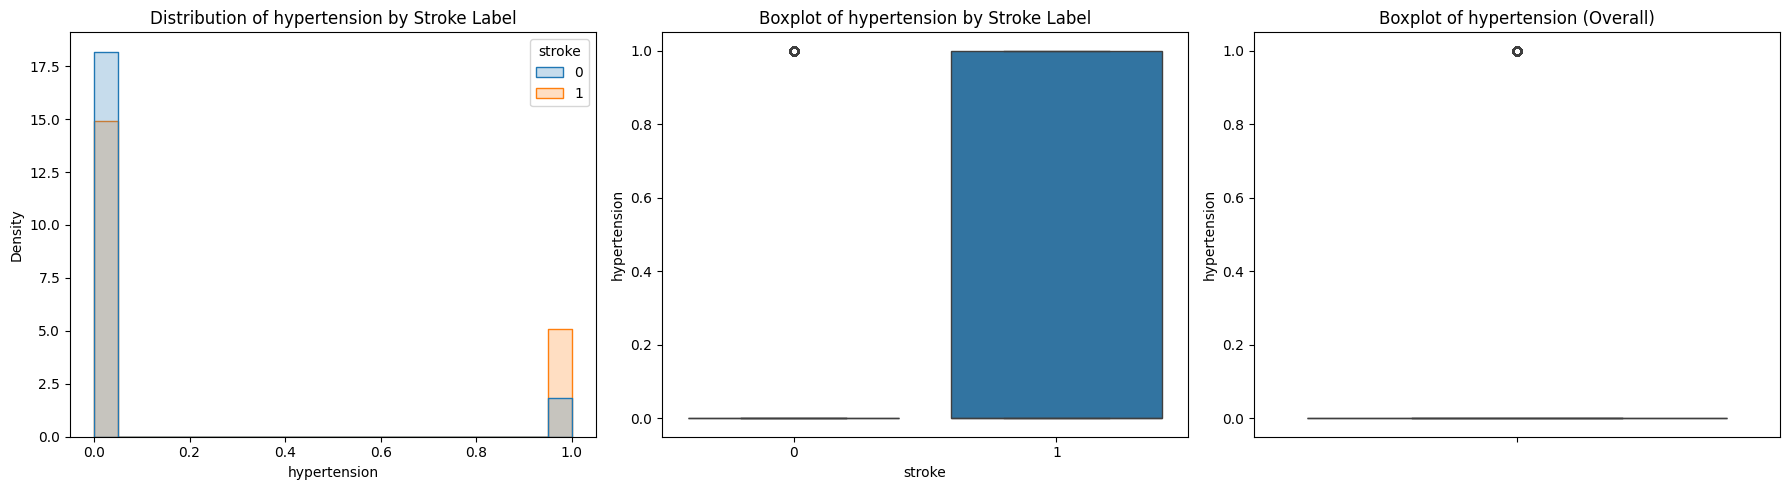

Distribution for hypertension:
  Stroke = 0: Skewness = 2.8527, Kurtosis = 6.1383
  Stroke = 1: Skewness = 1.1238, Kurtosis = -0.7390
-----------------------------------------


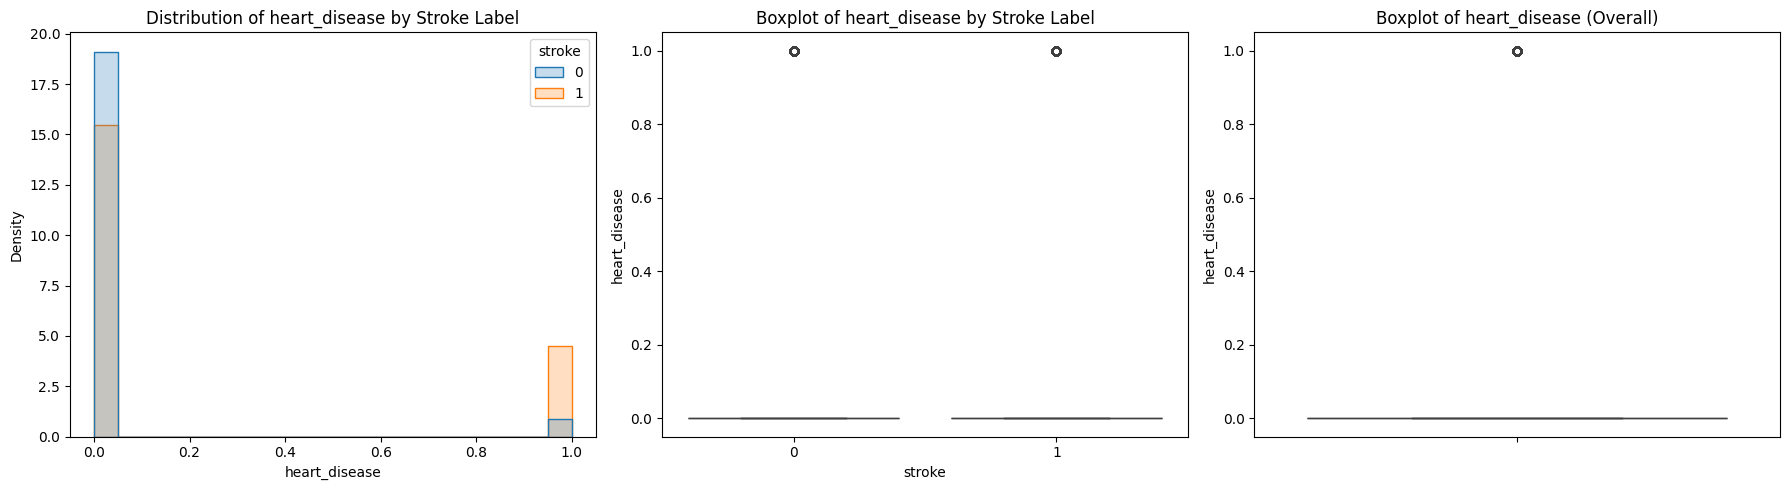

Distribution for heart_disease:
  Stroke = 0: Skewness = 4.4335, Kurtosis = 17.6570
  Stroke = 1: Skewness = 1.3124, Kurtosis = -0.2783
-----------------------------------------


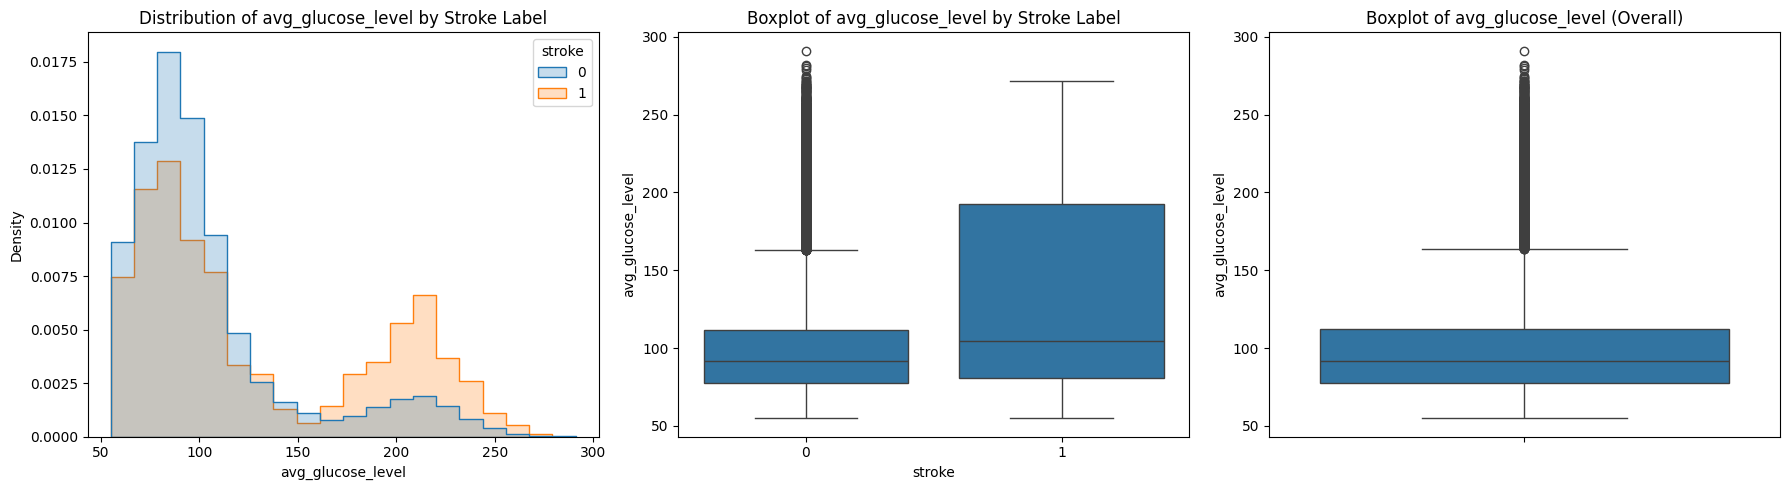

Distribution for avg_glucose_level:
  Stroke = 0: Skewness = 1.7006, Kurtosis = 2.3183
  Stroke = 1: Skewness = 0.6284, Kurtosis = -1.1261
-----------------------------------------


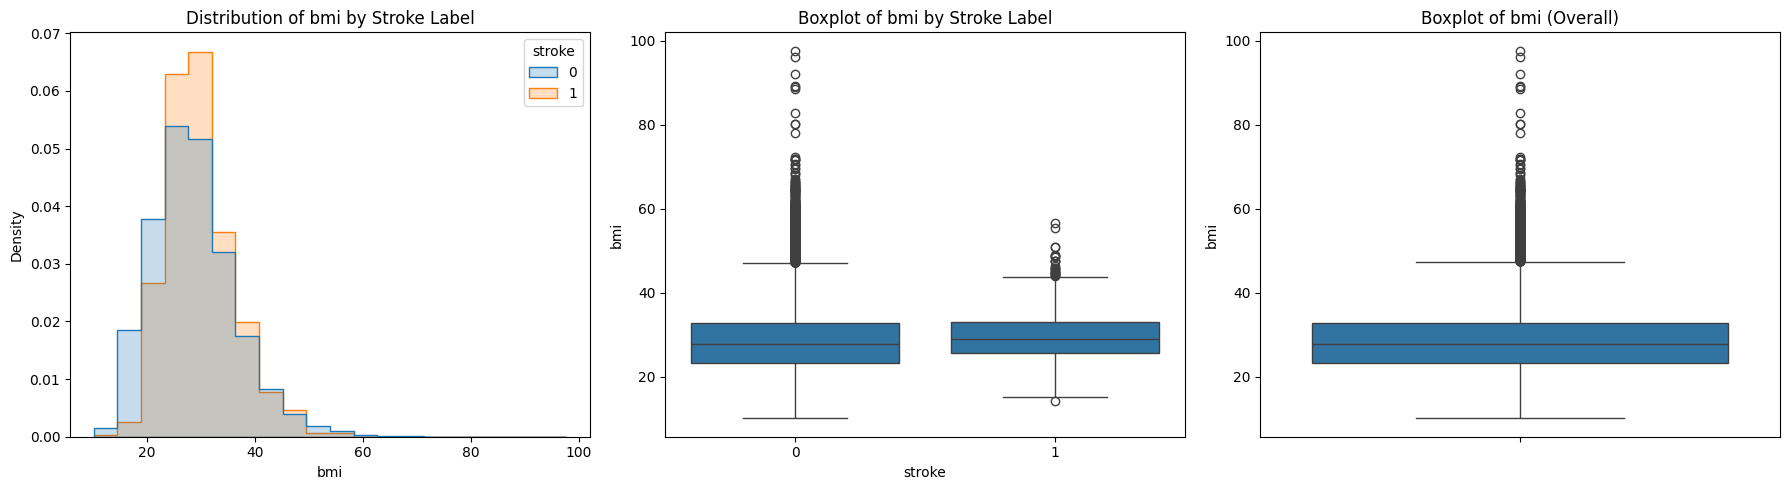

Distribution for bmi:
  Stroke = 0: Skewness = 0.9017, Kurtosis = 1.9929
  Stroke = 1: Skewness = 0.8383, Kurtosis = 1.1608
-----------------------------------------


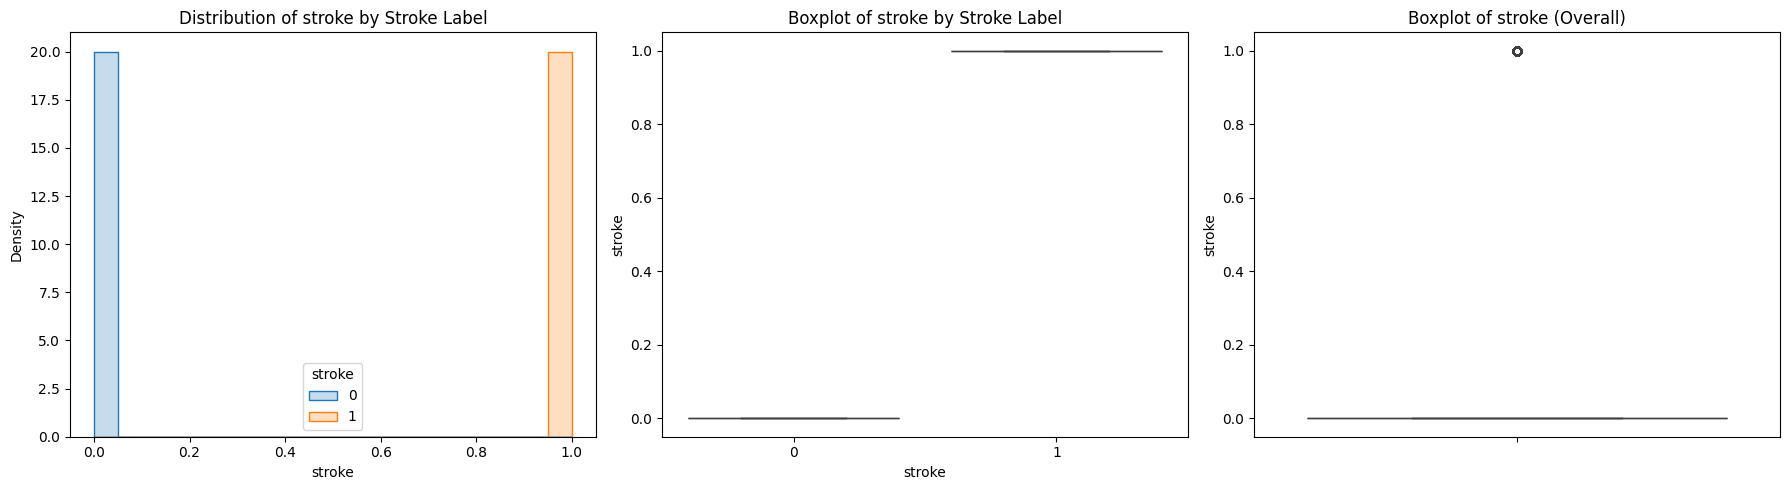

Distribution for stroke:
  Stroke = 0: Skewness = 0.0000, Kurtosis = 0.0000
  Stroke = 1: Skewness = 0.0000, Kurtosis = 0.0000
-----------------------------------------


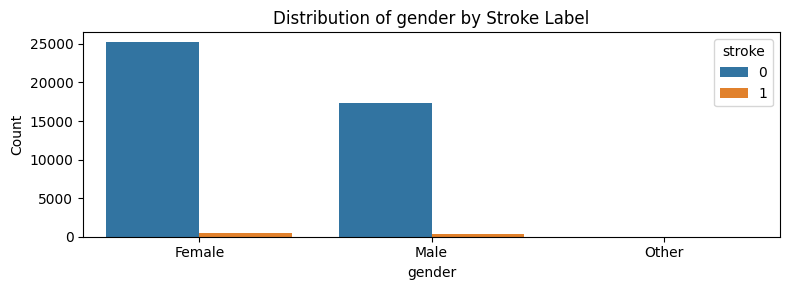


Overall distribution of gender:
gender
Female    59.135945
Male      40.838710
Other      0.025346
Name: proportion, dtype: float64

Distribution of gender for stroke = 0:
gender
Female    59.211113
Male      40.763076
Other      0.025811
Name: proportion, dtype: float64

Distribution of gender for stroke = 1:
gender
Female    55.0447
Male      44.9553
Name: proportion, dtype: float64
--------------------------------------------


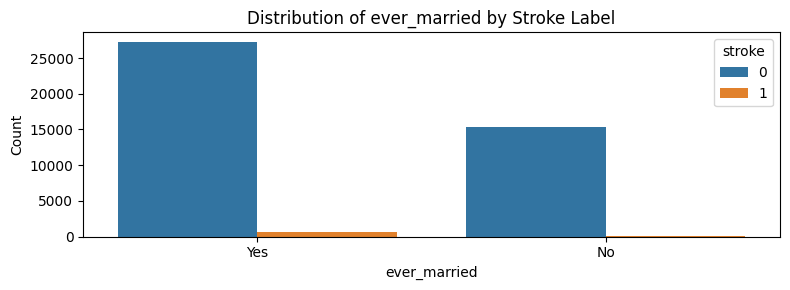


Overall distribution of ever_married:
ever_married
Yes    64.373272
No     35.626728
Name: proportion, dtype: float64

Distribution of ever_married for stroke = 0:
ever_married
Yes    63.906422
No     36.093578
Name: proportion, dtype: float64

Distribution of ever_married for stroke = 1:
ever_married
Yes    89.782886
No     10.217114
Name: proportion, dtype: float64
--------------------------------------------


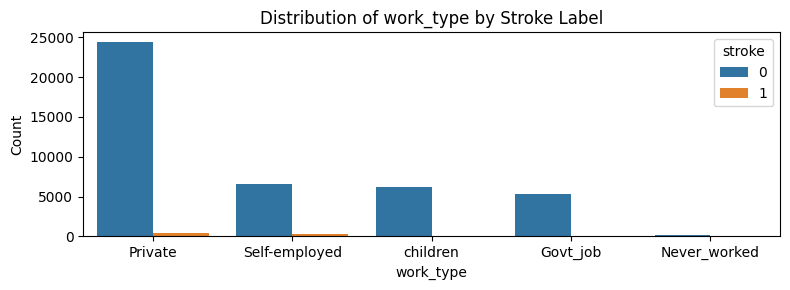


Overall distribution of work_type:
work_type
Private          57.221198
Self-employed    15.652074
children         14.184332
Govt_job         12.534562
Never_worked      0.407834
Name: proportion, dtype: float64

Distribution of work_type for stroke = 0:
work_type
Private          57.237722
Self-employed    15.350682
children         14.440247
Govt_job         12.556022
Never_worked      0.415327
Name: proportion, dtype: float64

Distribution of work_type for stroke = 1:
work_type
Private          56.321839
Self-employed    32.056194
Govt_job         11.366539
children          0.255428
Name: proportion, dtype: float64
--------------------------------------------


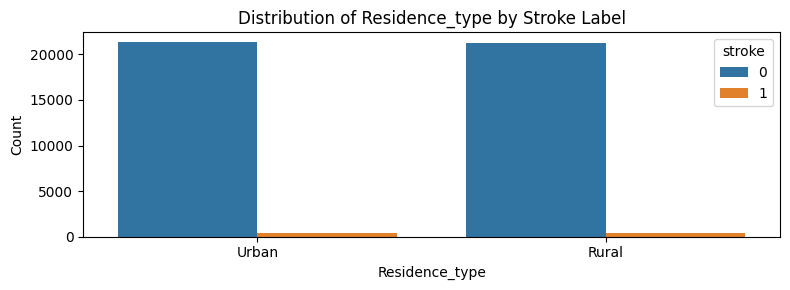


Overall distribution of Residence_type:
Residence_type
Urban    50.129032
Rural    49.870968
Name: proportion, dtype: float64

Distribution of Residence_type for stroke = 0:
Residence_type
Urban    50.113804
Rural    49.886196
Name: proportion, dtype: float64

Distribution of Residence_type for stroke = 1:
Residence_type
Urban    50.957854
Rural    49.042146
Name: proportion, dtype: float64
--------------------------------------------


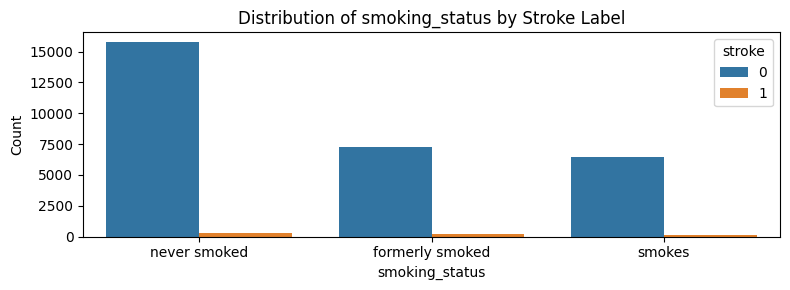


Overall distribution of smoking_status:
smoking_status
never smoked       53.318055
formerly smoked    24.887073
smokes             21.794872
Name: proportion, dtype: float64

Distribution of smoking_status for stroke = 0:
smoking_status
never smoked       53.508653
formerly smoked    24.675942
smokes             21.815405
Name: proportion, dtype: float64

Distribution of smoking_status for stroke = 1:
smoking_status
never smoked       44.514107
formerly smoked    34.639498
smokes             20.846395
Name: proportion, dtype: float64
--------------------------------------------


In [ ]:
num_col = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
cat_col = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
data[num_col] = data[num_col].apply(pd.to_numeric, errors='coerce')


def check_distribution(data, columns):
    for col in columns:

        plt.figure(figsize=(18, 5))


        plt.subplot(1, 3, 1)
        sns.histplot(data=data, x=col, hue='stroke', kde=False, bins=20, element="step", stat="density", common_norm=False)
        plt.title(f'Distribution of {col} by Stroke Label')

        plt.subplot(1, 3, 2)
        sns.boxplot(data=data, x='stroke', y=col)
        plt.title(f'Boxplot of {col} by Stroke Label')


        plt.subplot(1, 3, 3)
        sns.boxplot(data=data, y=col)
        plt.title(f'Boxplot of {col} (Overall)')

        plt.tight_layout()
        plt.show()


        print(f'Distribution for {col}:')

        for label in sorted(data['stroke'].dropna().unique()):
            subset = data[data['stroke'] == label][col].dropna()
            skewness = subset.skew()
            kurtosis = subset.kurt()
            print(f"  Stroke = {label}: Skewness = {skewness:.4f}, Kurtosis = {kurtosis:.4f}")

        print('-----------------------------------------')


check_distribution(data, num_col)


def check_categorical_distribution(data, columns):
    for col in columns:
        plt.figure(figsize=(8, 3))

        # Plot
        sns.countplot(x=data[col], hue=data['stroke'], order=data[col].value_counts().index)
        plt.title(f'Distribution of {col} by Stroke Label')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
        # Distribusi total (semua data)
        print(f"\nOverall distribution of {col}:")
        print(data[col].value_counts(normalize=True) * 100)

        # Distribusi per label stroke
        for label in sorted(data['stroke'].dropna().unique()):
            subset = data[data['stroke'] == label]
            print(f"\nDistribution of {col} for stroke = {label}:")
            print(subset[col].value_counts(normalize=True) * 100)

        print('--------------------------------------------')


check_categorical_distribution(data, cat_col)


## Train Test Split

In [ ]:
# X = datas.drop(columns='Survived')
# y = datas['Survived']

data = data[data['gender'] != 'Other'].copy()
X = data.copy() #drop y at the end of preprocessing
y = data['stroke']

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(34711, 12)

In [ ]:
y_train.shape

(34711,)

In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (X_train.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1152
smoking_status       10625
stroke                   0
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (X_test.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   306
smoking_status       2665
stroke                  0
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
X_train.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
30169,38885,Female,18.0,0,0,No,Private,Rural,60.67,28.2,formerly smoked,0
43186,66809,Male,1.4,0,0,No,children,Rural,149.04,20.3,NaN,0
17971,67688,Female,37.0,0,0,Yes,Private,Rural,153.99,28.3,smokes,0
31621,12620,Male,76.0,1,1,Yes,Private,Rural,213.17,NaN,never smoked,1
18362,53736,Male,32.0,0,0,Yes,Govt_job,Urban,78.38,42.8,never smoked,0


imputate children bmi

In [ ]:

age_stats = X_train.groupby('work_type')['age'].agg(['min', 'max'])

print("Minimum and maximum age for each work_type:")
print(age_stats)


Minimum and maximum age for each work_type:
                 min   max
work_type                 
Govt_job       13.00  82.0
Never_worked   13.00  64.0
Private         8.00  82.0
Self-employed   7.00  82.0
children        0.08  16.0


In [ ]:
# Check missing values in X_train for children
missing_bmi_train = X_train[(X_train['age'] < 17) & (X_train['bmi'].isnull())]
print(f"Missing BMI in X_train for children: {len(missing_bmi_train)}")

# Check missing values in X_test for children
missing_bmi_test = X_test[(X_test['age'] < 17) & (X_test['bmi'].isnull())]
print(f"Missing BMI in X_test for children: {len(missing_bmi_test)}")


Missing BMI in X_train for children: 86
Missing BMI in X_test for children: 19


Number of missing BMI for 'children' in work_type: 77 out of 4921 (1.56%)


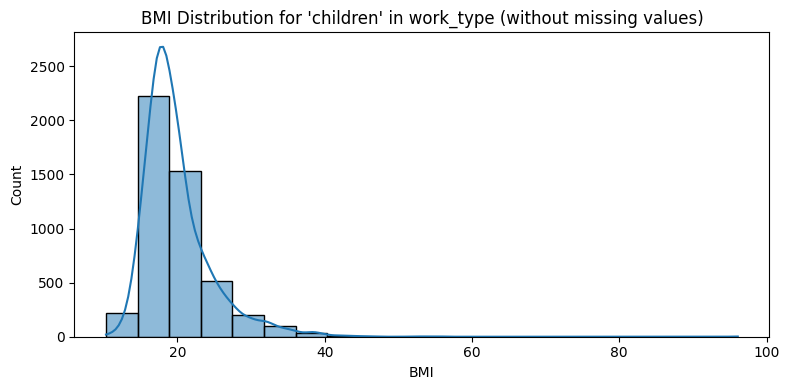

Skewness of BMI (work_type='children'): 2.4637
Kurtosis of BMI (work_type='children'): 17.5468


In [ ]:
# Filter data with work_type 'children' in X_train
children_data = X_train[X_train['work_type'] == 'children']

# Check missing BMI
missing_bmi_count = children_data['bmi'].isnull().sum()
total_children = len(children_data)

print(f"Number of missing BMI for 'children' in work_type: {missing_bmi_count} out of {total_children} ({missing_bmi_count / total_children * 100:.2f}%)")

# Drop missing BMI
children_notnull = children_data.dropna(subset=['bmi'])


plt.figure(figsize=(8, 4))
sns.histplot(data=children_notnull, x='bmi', bins=20, kde=True)
plt.title("BMI Distribution for 'children' in work_type (without missing values)")
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

skewness = children_notnull['bmi'].skew()
kurtosis = children_notnull['bmi'].kurt()
print(f"Skewness of BMI (work_type='children'): {skewness:.4f}")
print(f"Kurtosis of BMI (work_type='children'): {kurtosis:.4f}")


In [ ]:

def get_age_range(age):
    if 0 <= age <= 5:
        return '0-5'
    elif 6 <= age <= 11:
        return '6-11'
    elif 12 <= age <= 16:
        return '12-16'
    else:
        return None

# Add age_range column to X_train
X_train = X_train.copy()
X_train['age_range'] = X_train['age'].apply(get_age_range)

# Filter only data for ages 0-16 with non-null BMI
filtered = X_train[(X_train['age_range'].notnull()) & (X_train['bmi'].notnull())]

# Calculate median BMI based on work_type, gender, age_range, residence_type
median_bmi = filtered.groupby(['work_type', 'gender', 'age_range', 'Residence_type'])['bmi'].median()

print("Median BMI per work_type, gender, age_range, and residence_type (ages 0–16):")
print(median_bmi)

def imputasi_bmi(row, median_dict):
    age_range = get_age_range(row['age'])
    if pd.isna(row['bmi']) and age_range is not None:
        key = (row['work_type'], row['gender'], age_range, row['Residence_type'])
        return median_dict[key]  # Ensured there are no missing combinations
    else:
        return row['bmi']

# Impute BMI only for ages 0-16
X_train['bmi'] = X_train.apply(lambda row: imputasi_bmi(row, median_bmi), axis=1)
X_test['age_range'] = X_test['age'].apply(get_age_range)
X_test['bmi'] = X_test.apply(lambda row: imputasi_bmi(row, median_bmi), axis=1)


missing_train = X_train[(X_train['age_range'].notnull()) & (X_train['bmi'].isnull())].shape[0]
missing_test = X_test[(X_test['age_range'].notnull()) & (X_test['bmi'].isnull())].shape[0]

print(f"Missing BMI in X_train (ages 0–16) after imputation: {missing_train}")
print(f"Missing BMI in X_test (ages 0–16) after imputation: {missing_test}")


Median BMI per work_type, gender, age_range, and residence_type (ages 0–16):
work_type      gender  age_range  Residence_type
Govt_job       Female  12-16      Rural             25.20
                                  Urban             25.95
               Male    12-16      Rural             28.10
                                  Urban             23.90
Never_worked   Female  12-16      Rural             23.80
                                  Urban             22.90
               Male    12-16      Rural             24.20
                                  Urban             23.40
Private        Female  12-16      Rural             24.10
                                  Urban             24.00
                       6-11       Urban             17.60
               Male    12-16      Rural             24.00
                                  Urban             24.05
Self-employed  Female  12-16      Rural             24.05
                                  Urban             24.10
    

In [ ]:
X_train_backup_imputate_children = X_train.copy()
X_test_backup_imputate_children = X_test.copy()

In [ ]:
X_train = X_train_backup_imputate_children.copy()
X_test = X_test_backup_imputate_children.copy()

imputate all bmi

In [ ]:
#  determine age range in 5-year intervals for age > 16
def get_age_range_adult(age):
    if age <= 16:
        return None
    else:
        lower = int((age - 17) // 5) * 5 + 17
        upper = lower + 4
        return f'{lower}-{upper}'


X_train['age_range_adult'] = X_train['age'].apply(get_age_range_adult)


filtered_adult = X_train[(X_train['age_range_adult'].notnull()) & (X_train['bmi'].notnull())]

# Calculate median BMI based on work_type, gender, age_range_adult, residence_type, ever_married
median_bmi_adult = filtered_adult.groupby(
    ['work_type', 'gender', 'age_range_adult', 'Residence_type', 'ever_married']
)['bmi'].median()

print("Median BMI (age > 16) by work_type, gender, age_range_adult, residence_type, and ever_married:")
print(median_bmi_adult)


def imputasi_bmi_adult(row, median_dict):
    age_range = get_age_range_adult(row['age'])
    if pd.isna(row['bmi']) and age_range is not None:
        key = (row['work_type'], row['gender'], age_range, row['Residence_type'], row['ever_married'])
        if key in median_dict:
            return median_dict[key]
        else:
            return row['bmi']  # leave as NaN if the combination is not found
    else:
        return row['bmi']

X_train['bmi'] = X_train.apply(lambda row: imputasi_bmi_adult(row, median_bmi_adult), axis=1)
X_test['age_range_adult'] = X_test['age'].apply(get_age_range_adult)
X_test['bmi'] = X_test.apply(lambda row: imputasi_bmi_adult(row, median_bmi_adult), axis=1)

missing_train_adult = X_train[(X_train['age'] > 16) & (X_train['bmi'].isnull())].shape[0]
missing_test_adult = X_test[(X_test['age'] > 16) & (X_test['bmi'].isnull())].shape[0]

print(f"Missing BMI in X_train (age > 16) after imputation: {missing_train_adult}")
print(f"Missing BMI in X_test (age > 16) after imputation: {missing_test_adult}")


Median BMI (age > 16) by work_type, gender, age_range_adult, residence_type, and ever_married:
work_type      gender  age_range_adult  Residence_type  ever_married
Govt_job       Female  17-21            Rural           No              25.05
                                        Urban           No              25.50
                                                        Yes             20.05
                       22-26            Rural           No              25.10
                                                        Yes             24.90
                                                                        ...  
Self-employed  Male    77-81            Urban           Yes             27.80
                       82-86            Rural           No              26.60
                                                        Yes             28.20
                                        Urban           No              28.25
                                                        

In [ ]:
X_train[X_train['bmi'].isna()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_range,age_range_adult
38352,20581,Male,82.0,0,1,No,Govt_job,Urban,130.02,NaN,formerly smoked,0,None,82-86


In [ ]:

median_bmi = X_train['bmi'].median()

print("Median BMI for the entire dataset:", median_bmi)
X_train['bmi'] = X_train['bmi'].fillna(median_bmi)


Median BMI for the entire dataset: 27.9


In [ ]:
X_train_impute_all_bmi = X_train.copy()
X_test_impute_all_bmi = X_test.copy()

In [ ]:
X_train = X_train_impute_all_bmi.copy()
X_test = X_test_impute_all_bmi.copy()

#imputate smoke status

In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (X_train.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                      0
smoking_status       10625
stroke                   0
age_range            29052
age_range_adult       5659
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
# 1. Filter children under 17 years old
under17 = X_train[X_train['age'] < 17].copy()


smoked_status = ['formerly smoked', 'smokes']
under17['ever_smoked'] = under17['smoking_status'].isin(smoked_status)


under17['has_condition'] = (under17['hypertension'] == 1) | (under17['heart_disease'] == 1)


prop_table = under17.groupby(['has_condition', 'ever_smoked']).size().unstack(fill_value=0)
prop_table['Total'] = prop_table.sum(axis=1)
prop_table['Proportion_True'] = prop_table[True] / prop_table['Total']
prop_table['Proportion_False'] = prop_table[False] / prop_table['Total']
print(prop_table)


ever_smoked    False  True  Total  Proportion_True  Proportion_False
has_condition                                                       
False           5496   156   5652         0.027601          0.972399
True               7     0      7         0.000000          1.000000


imputate smoke age <17

In [ ]:

smokers_under_17 = X_train[
    (X_train['age'] < 17) &
    (X_train['smoking_status'].isin(['formerly smoked', 'smokes']))
]

print(f"Number of individuals under 17 who have ever smoked: {len(smokers_under_17)}")
smokers_under_17.head()


Number of individuals under 17 who have ever smoked: 156


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_range,age_range_adult
11514,16839,Female,13.0,0,0,No,children,Rural,83.84,19.2,formerly smoked,0,12-16,None
16483,67440,Female,15.0,0,0,No,Private,Urban,88.59,27.8,formerly smoked,0,12-16,None
25326,66709,Male,15.0,0,0,No,children,Rural,97.56,20.4,formerly smoked,0,12-16,None
1896,9199,Male,13.0,0,0,No,Self-employed,Urban,74.19,31.1,formerly smoked,0,12-16,None
38372,72842,Female,15.0,0,0,No,Private,Rural,81.14,30.5,smokes,0,12-16,None


In [ ]:

df_under_17 = X_train[X_train['age'] < 17]
summary_detail = df_under_17.groupby(['work_type', 'gender', 'smoking_status']).size().unstack(fill_value=0)

print(summary_detail)


smoking_status        formerly smoked  never smoked  smokes
work_type     gender                                       
Govt_job      Female                0             9       1
              Male                  2             6       1
Never_worked  Female                1            20       1
              Male                  1            15       1
Private       Female               19           137      14
              Male                 15           123       6
Self-employed Female                2            15       0
              Male                  1            15       0
children      Female               44           226       1
              Male                 43           198       3


In [ ]:

before_impute_train = X_train[X_train['age'] < 17].copy()
before_impute_test = X_test[X_test['age'] < 17].copy()


In [ ]:
# Direct imputation for children under 17 as 'never smoked'
X_train.loc[(X_train['age'] < 17) & (X_train['smoking_status'].isna()), 'smoking_status'] = 'never smoked'
X_test.loc[(X_test['age'] < 17) & (X_test['smoking_status'].isna()), 'smoking_status'] = 'never smoked'


In [ ]:
after_impute_train = X_train[X_train['age'] < 17].copy()
after_impute_test = X_test[X_test['age'] < 17].copy()


In [ ]:
print("=== X_train ===")
print("Before imputation:", before_impute_train['smoking_status'].isna().sum())
print("After imputation:", after_impute_train['smoking_status'].isna().sum())

print("\n=== X_test ===")
print("Before imputation:", before_impute_test['smoking_status'].isna().sum())
print("After imputation:", after_impute_test['smoking_status'].isna().sum())


=== X_train ===
Before imputation: 4739
After imputation: 0

=== X_test ===
Before imputation: 1197
After imputation: 0


In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (X_train.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                      0
smoking_status        5886
stroke                   0
age_range            29052
age_range_adult       5659
dtype: int64
------------------------------
Duplicate Values :  0


In [ ]:
X_train_backup_imputate_smoking_status_children = X_train.copy()
X_test_backup_imputate_smoking_status_children = X_test.copy()

In [ ]:
X_train = X_train_backup_imputate_smoking_status_children.copy()
X_test = X_test_backup_imputate_smoking_status_children.copy()

imputate age >17

In [ ]:
# Filter data for age < 30
df_under_17 = X_train[X_train['age'] < 30]

summary_detail = df_under_17.groupby(['work_type', 'gender', 'smoking_status']).size().unstack(fill_value=0)

print(summary_detail)


smoking_status        formerly smoked  never smoked  smokes
work_type     gender                                       
Govt_job      Female               46           167      56
              Male                 19            87      34
Never_worked  Female                2            63       3
              Male                  2            42       3
Private       Female              366          1730     525
              Male                180           895     320
Self-employed Female               21           102      35
              Male                 12            70      17
children      Female               44          2333       1
              Male                 43          2497       3


In [ ]:
# 1. Filter adults aged 65 and above
under17 = X_train[X_train['age'] >= 65].copy()


smoked_status = ['formerly smoked', 'smokes']
under17['ever_smoked'] = under17['smoking_status'].isin(smoked_status)

under17['has_condition'] = (under17['hypertension'] == 1) | (under17['heart_disease'] == 1)


prop_table = under17.groupby(['has_condition', 'ever_smoked']).size().unstack(fill_value=0)


prop_table['Total'] = prop_table.sum(axis=1)
prop_table['Proportion_True'] = prop_table[True] / prop_table['Total']
prop_table['Proportion_False'] = prop_table[False] / prop_table['Total']
print(prop_table)


ever_smoked    False  True  Total  Proportion_True  Proportion_False
has_condition                                                       
False           2513  1827   4340         0.420968          0.579032
True            1190  1003   2193         0.457364          0.542636


In [ ]:
import pandas as pd

# Create age category column in X_train
bins = [17, 30, 40, 50, 65, float('inf')]
labels = ['17-30', '31-40', '41-50', '51-65', '65+']
X_train = X_train.copy()
X_train['age_group_new'] = pd.cut(X_train['age'], bins=bins, labels=labels, right=True)
result_train = X_train.groupby('age_group_new')['smoking_status'].value_counts(dropna=False).unstack(fill_value=0)

print("Smoking status distribution in X_train:")
print(result_train)


Smoking status distribution in X_train:
smoking_status   NaN  formerly smoked  never smoked  smokes
age_group_new                                              
17-30           1219              638          2488    1048
31-40            896              644          1989     884
41-50            999              836          2155    1101
51-65           1385             1812          3046    1411
65+             1231             1873          2253     754


/tmp/ipython-input-3496859089.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_train = X_train.groupby('age_group_new')['smoking_status'].value_counts(dropna=False).unstack(fill_value=0)


In [ ]:
X_train.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_range,age_range_adult,age_group_new
30169,38885,Female,18.0,0,0,No,Private,Rural,60.67,28.2,formerly smoked,0,None,17-21,17-30
43186,66809,Male,1.4,0,0,No,children,Rural,149.04,20.3,never smoked,0,0-5,None,NaN
17971,67688,Female,37.0,0,0,Yes,Private,Rural,153.99,28.3,smokes,0,None,37-41,31-40
31621,12620,Male,76.0,1,1,Yes,Private,Rural,213.17,29.4,never smoked,1,None,72-76,65+
18362,53736,Male,32.0,0,0,Yes,Govt_job,Urban,78.38,42.8,never smoked,0,None,32-36,31-40


In [ ]:


features = ["age", "gender", "hypertension", "heart_disease", "ever_married", "work_type", "smoking_status"]

train = X_train[features].copy()
test = X_test[features].copy()

le_smoke = LabelEncoder()
le_smoke.fit(train["smoking_status"])


train["smoking_status_encoded"] = train["smoking_status"].map(
    lambda x: le_smoke.transform([x])[0] if pd.notnull(x) else np.nan
)

def safe_transform(val):
    if pd.isnull(val):
        return np.nan
    elif val in le_smoke.classes_:
        return le_smoke.transform([val])[0]
    else:
        return np.nan

test["smoking_status_encoded"] = test["smoking_status"].map(safe_transform)

numeric_features = ["age"]
categorical_features = ["gender", "ever_married", 'work_type']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("imputer", KNNImputer(n_neighbors=5))
])

train_input = pd.concat([
    train.drop(columns=["smoking_status", "smoking_status_encoded"]),
    train["smoking_status_encoded"]
], axis=1)


pipeline.fit(train_input)


train_imputed = pipeline.transform(train_input)


test_input = pd.concat([
    test.drop(columns=["smoking_status", "smoking_status_encoded"]),
    test["smoking_status_encoded"]
], axis=1)
test_imputed = pipeline.transform(test_input)

train_smoke_imputed = train_imputed[:, -1].round().astype(int)
test_smoke_imputed = test_imputed[:, -1].round().astype(int)

train["smoking_status_imputed"] = le_smoke.inverse_transform(train_smoke_imputed)
test["smoking_status_imputed"] = le_smoke.inverse_transform(test_smoke_imputed)




In [ ]:
X_train["smoking_status"].value_counts()
X_test["smoking_status"].value_counts()


,count
smoking_status,
never smoked,4369
formerly smoked,1527
smokes,1314


In [ ]:
X_train["smoking_status_imputed"] = train["smoking_status_imputed"]
X_test["smoking_status_imputed"] = test["smoking_status_imputed"]

In [ ]:
X_train["smoking_status_imputed"].value_counts()
X_test["smoking_status_imputed"].value_counts()


,count
smoking_status_imputed,
never smoked,5569
formerly smoked,1646
smokes,1463


In [ ]:
#MISSING VALUE

print ("Missing Values : ")
print (X_train.isnull().sum())
print ("------------------------------")
print ("Duplicate Values : ", str(data.duplicated().sum()))



Missing Values : 
id                            0
gender                        0
age                           0
hypertension                  0
heart_disease                 0
ever_married                  0
work_type                     0
Residence_type                0
avg_glucose_level             0
bmi                           0
smoking_status             5886
stroke                        0
age_range                 29052
age_range_adult            5659
age_group_new              6049
smoking_status_imputed        0
dtype: int64
------------------------------
Duplicate Values :  0


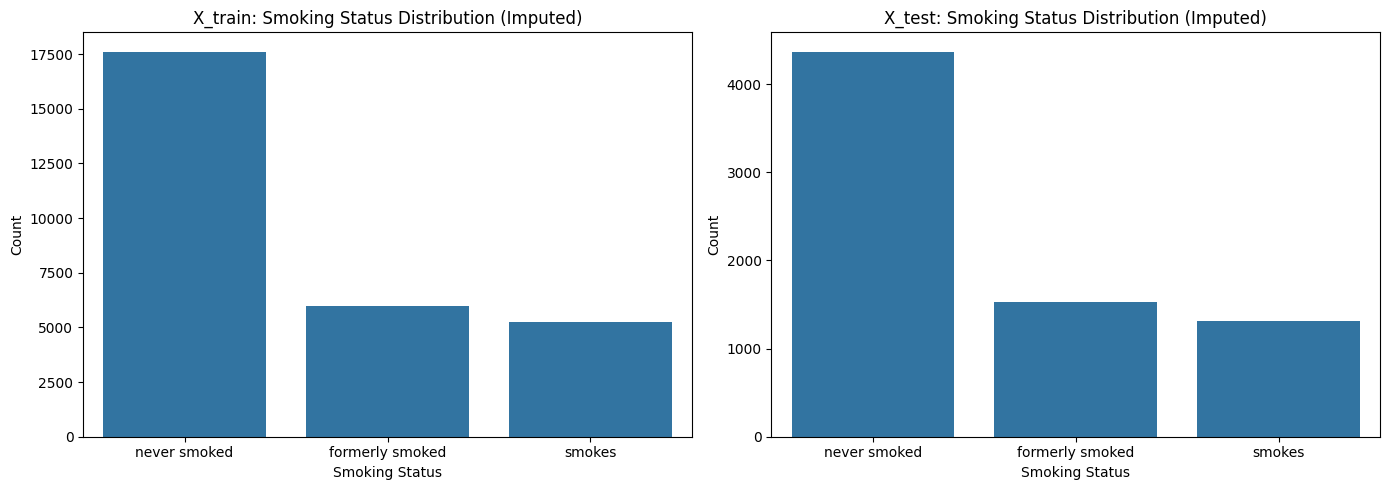

In [ ]:


# --- Distribution before and after imputation ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Train
sns.countplot(x=X_train["smoking_status"], order=X_train["smoking_status"].value_counts().index, ax=axes[0])
axes[0].set_title("X_train: Smoking Status Distribution (Imputed)")
axes[0].set_xlabel("Smoking Status")
axes[0].set_ylabel("Count")

# Test
sns.countplot(x=X_test["smoking_status"], order=X_test["smoking_status"].value_counts().index, ax=axes[1])
axes[1].set_title("X_test: Smoking Status Distribution (Imputed)")
axes[1].set_xlabel("Smoking Status")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


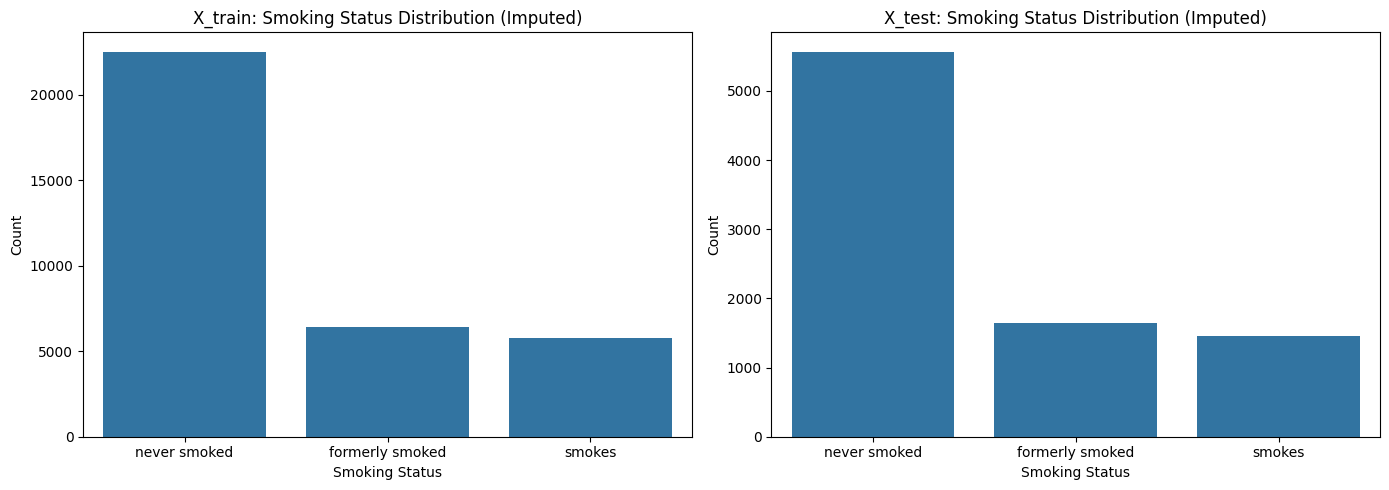

In [ ]:


# --- Distribution before and after imputation ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Train
sns.countplot(x=X_train["smoking_status_imputed"], order=X_train["smoking_status_imputed"].value_counts().index, ax=axes[0])
axes[0].set_title("X_train: Smoking Status Distribution (Imputed)")
axes[0].set_xlabel("Smoking Status")
axes[0].set_ylabel("Count")

# Test
sns.countplot(x=X_test["smoking_status_imputed"], order=X_test["smoking_status_imputed"].value_counts().index, ax=axes[1])
axes[1].set_title("X_test: Smoking Status Distribution (Imputed)")
axes[1].set_xlabel("Smoking Status")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:
X_train = X_train.drop(columns=['id','smoking_status','age_range_adult','age_group_new','age_range'],errors='ignore')
X_test = X_test.drop(columns=['id','smoking_status','age_range_adult','age_group_new','age_range'],errors='ignore')

In [ ]:
X_train_final = X_train.copy()
X_test_final = X_test.copy()

In [ ]:
X_train = X_train_final.copy()
X_test = X_test_final.copy()

In [ ]:
X_train.shape

(34711, 11)

In [ ]:
y_train.shape

(34711,)

In [ ]:
X_test.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,smoking_status_imputed
16343,Female,27.0,0,0,No,Private,Urban,108.01,23.7,0,never smoked
18251,Female,30.0,0,0,Yes,Private,Rural,236.20,26.9,0,smokes
42169,Male,76.0,0,0,Yes,Self-employed,Urban,117.91,35.2,0,smokes
36434,Female,62.0,1,0,Yes,Self-employed,Urban,138.37,27.7,0,never smoked
40469,Male,58.0,1,0,Yes,Self-employed,Rural,218.41,29.5,0,smokes


## FINAL PREPROCESSING

In [ ]:

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_features = ["age", "bmi", "avg_glucose_level"]
scaler = RobustScaler()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_scaled[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_scaled[numeric_features])

binary_features = ["gender", "ever_married", "Residence_type"]
le_dict = {}
for col in binary_features:
    if X_train_scaled[col].dtype == 'object':
        le = LabelEncoder()
        X_train_scaled[col] = le.fit_transform(X_train_scaled[col])
        X_test_scaled[col] = X_test_scaled[col].map(
            lambda x: le.transform([x])[0] if x in le.classes_ else 0
        )
        le_dict[col] = le

ohe_features = ["work_type", "smoking_status_imputed"]
X_train_processed = pd.get_dummies(X_train_scaled, columns=ohe_features)
X_test_processed = pd.get_dummies(X_test_scaled, columns=ohe_features)




In [ ]:
ohe_cols = [col for col in X_train_processed.columns if any(feat in col for feat in ohe_features)]
X_train_processed[ohe_cols] = X_train_processed[ohe_cols].astype(np.int64)
X_test_processed[ohe_cols] = X_test_processed[ohe_cols].astype(np.int64)


In [ ]:
X_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34711 entries, 30169 to 15795
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   gender                                  34711 non-null  int64  
 1   age                                     34711 non-null  float64
 2   hypertension                            34711 non-null  int64  
 3   heart_disease                           34711 non-null  int64  
 4   ever_married                            34711 non-null  int64  
 5   Residence_type                          34711 non-null  int64  
 6   avg_glucose_level                       34711 non-null  float64
 7   bmi                                     34711 non-null  float64
 8   stroke                                  34711 non-null  int64  
 9   work_type_Govt_job                      34711 non-null  int64  
 10  work_type_Never_worked                  34711 non-null  int

In [ ]:
X_test_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8678 entries, 16343 to 6662
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   gender                                  8678 non-null   int64  
 1   age                                     8678 non-null   float64
 2   hypertension                            8678 non-null   int64  
 3   heart_disease                           8678 non-null   int64  
 4   ever_married                            8678 non-null   int64  
 5   Residence_type                          8678 non-null   int64  
 6   avg_glucose_level                       8678 non-null   float64
 7   bmi                                     8678 non-null   float64
 8   stroke                                  8678 non-null   int64  
 9   work_type_Govt_job                      8678 non-null   int64  
 10  work_type_Never_worked                  8678 non-null   int64

In [ ]:
X_train_processed_backup = X_train_processed.copy()
X_test_processed_backup = X_test_processed.copy()


In [ ]:

X_train = X_train_processed_backup.copy()
X_test = X_test_processed_backup.copy()

In [ ]:
# Scale so we are not limited to only tree based method

In [ ]:
X_train_processed.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_imputed_formerly smoked,smoking_status_imputed_never smoked,smoking_status_imputed_smokes
30169,0,-0.722222,0,0,0,0,-0.891455,0.032258,0,0,0,1,0,0,1,0,0
43186,1,-1.183333,0,0,0,0,1.659642,-0.817204,0,0,0,0,0,1,0,1,0
17971,0,-0.194444,0,0,1,0,1.802540,0.043011,0,0,0,1,0,0,0,0,1
31621,1,0.888889,1,1,1,0,3.510970,0.161290,1,0,0,1,0,0,0,1,0
18362,1,-0.333333,0,0,1,1,-0.380196,1.602151,0,1,0,0,0,0,0,1,0


In [ ]:
# try autoencoder for one class classification(didnt work)

In [ ]:

X_train_normal = X_train_processed[X_train_processed["stroke"] == 0].drop(columns=["stroke"]).values
X_test_input = X_test_processed.drop(columns=["stroke"]).values  # test set

input_dim = X_train_normal.shape[1]


input_layer = Input(shape=(input_dim,))


encoded = Dense(128, activation='relu', activity_regularizer=regularizers.l2(1e-5))(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)


decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')




In [ ]:

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

X_train_pred = autoencoder.predict(X_train_normal)
mse_train = np.mean(np.square(X_train_normal - X_train_pred), axis=1)

Epoch 1/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0760 - val_loss: 0.0031
Epoch 2/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 3/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0013 - val_loss: 9.9890e-04
Epoch 4/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.0368e-04 - val_loss: 7.1620e-04
Epoch 5/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.1005e-04 - val_loss: 7.6646e-04
Epoch 6/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6.2697e-04 - val_loss: 6.2679e-04
Epoch 7/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.4847e-04 - val_loss: 6.8534e-04
Epoch 8/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.7218e-04 - val_loss: 3.2239e-04
Epoch 9/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.2800e-04 - val_loss: 5.6002e-04
Epoch 10/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.5819e-04 - val_loss: 2.5474e-04
Epoch 11/30
959/959 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.6294e-04 - val_l

In [ ]:

X_train_pred = autoencoder.predict(X_train_normal)
mse_train = np.mean(np.square(X_train_normal - X_train_pred), axis=1)


threshold = mse_train.mean() + 3 * mse_train.std()
print("Reconstruction error threshold:", threshold)


X_test_pred = autoencoder.predict(X_test_input)
mse_test = np.mean(np.square(X_test_input - X_test_pred), axis=1)


stroke_pred = (mse_test > threshold).astype(int)

-
print("Number of predicted stroke=1 in test:", np.sum(stroke_pred))


1065/1065 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Reconstruction error threshold: 0.0006428131926230376
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Number of predicted stroke=1 in test: 185


In [ ]:



print(classification_report(y_test, stroke_pred, target_names=['Normal', 'Stroke']))
print(confusion_matrix(y_test, stroke_pred))


              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      8529
      Stroke       0.06      0.08      0.07       149

    accuracy                           0.96      8678
   macro avg       0.52      0.53      0.53      8678
weighted avg       0.97      0.96      0.97      8678

[[8356  173]
 [ 137   12]]


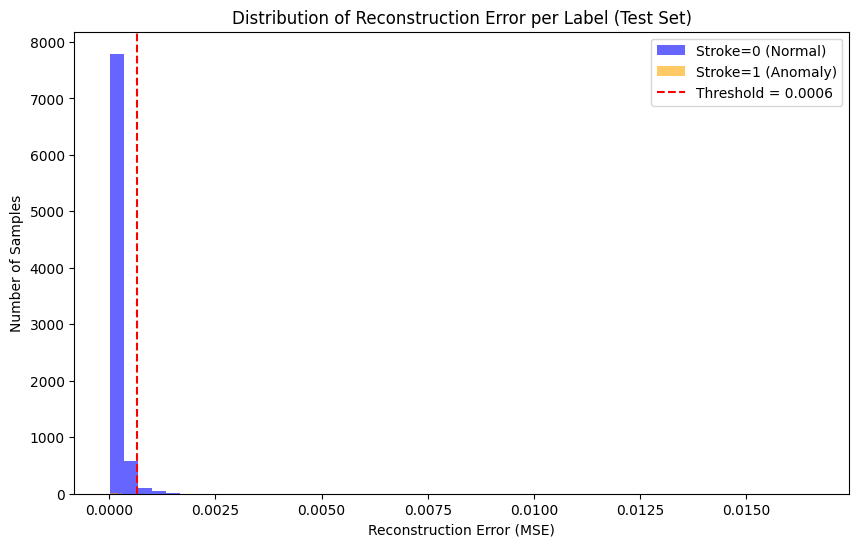

In [ ]:

mse_test_0 = mse_test[y_test == 0]   # normal
mse_test_1 = mse_test[y_test == 1]   # stroke

plt.figure(figsize=(10,6))
plt.hist(mse_test_0, bins=50, alpha=0.6, color='blue', label='Stroke=0 (Normal)')
plt.hist(mse_test_1, bins=50, alpha=0.6, color='orange', label='Stroke=1 (Anomaly)')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.title("Distribution of Reconstruction Error per Label (Test Set)")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()


In [ ]:


X_train_processed_no_y = X_train_processed.drop(columns=['stroke'],errors='ignore')
X_test_processed_no_y = X_test_processed.drop(columns=['stroke'],errors='ignore')


In [ ]:
X_train_processed.shape

(34711, 17)

In [ ]:
y_train.shape

(34711,)

In [ ]:
def plot_2d_space(X, y, label='Classes'):
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],
            X[y==l, 1],
            c=c, label=l, marker=m
        )
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()

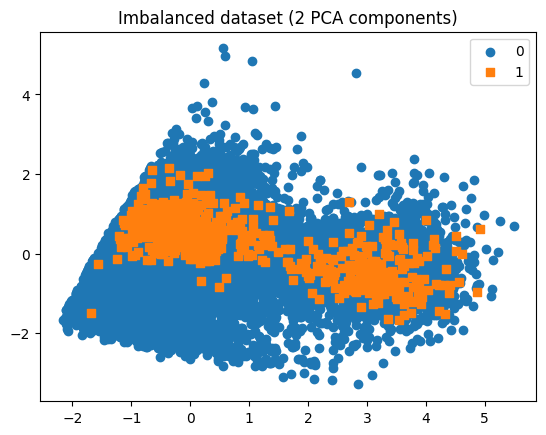

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_component = pca.fit_transform(X_train_processed_no_y)

plot_2d_space(X_component, y_train, 'Imbalanced dataset (2 PCA components)')

In [ ]:
y_train.shape

(34711,)

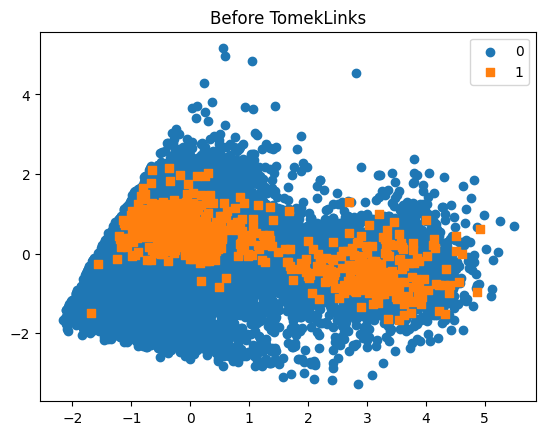

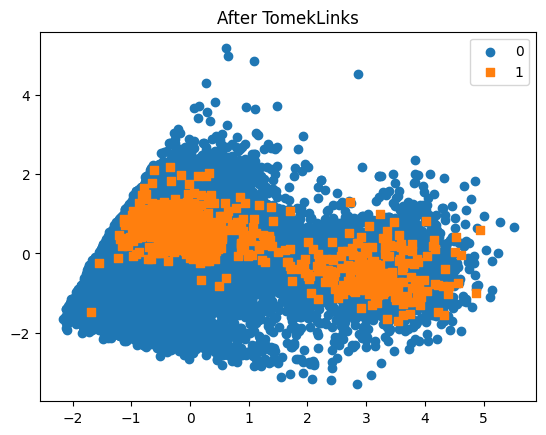

In [ ]:

pca = PCA(n_components=2)

plot_2d_space(X_component, y_train, 'Before TomekLinks')

# Apply TomekLinks (remove majority class that is too close to minority class)
tl = TomekLinks(sampling_strategy='majority')
X_res, y_res = tl.fit_resample(X_train_processed_no_y, y_train)


X_pca_after = pca.fit_transform(X_res)  # re-fit PCA on resampled data
plot_2d_space(X_pca_after, y_res, 'After TomekLinks')


In [ ]:
print("Before TomekLinks:")
print(y_train.value_counts())

print("\nAfter TomekLinks:")
print(y_res.value_counts())

Before TomekLinks:
stroke
0    34077
1      634
Name: count, dtype: int64

After TomekLinks:
stroke
0    33737
1      634
Name: count, dtype: int64


In [ ]:
X_train_processed_no_y.shape

(34711, 16)

In [ ]:
y_train.shape

(34711,)

After Tomek Links:
Total data: 34371
Majority: 33737
Minority: 634

After clustering-based undersampling (combined with Tomek Links):
Total data: 2317
Majority: 1683
Minority: 634


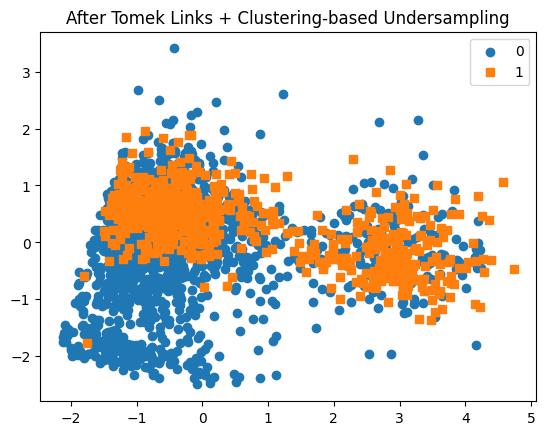

In [ ]:

X_data = X_train_processed_no_y.copy().reset_index(drop=True)
y_data = y_train.copy().reset_index(drop=True)

tl = TomekLinks(sampling_strategy='majority')  # remove majority class that is too close to the minority class
X_tl, y_tl = tl.fit_resample(X_data, y_data)

print("After Tomek Links:")
print("Total data:", len(y_tl))
print("Majority:", sum(y_tl==0))
print("Minority:", sum(y_tl==1))

X_majority = X_tl[y_tl==0]
y_majority = y_tl[y_tl==0]
X_minority = X_tl[y_tl==1]
y_minority = y_tl[y_tl==1]

n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_majority)


remove_ratio = 0.95
selected_idx = []
for c in range(n_clusters):
    cluster_idx = np.where(clusters==c)[0]
    n_keep = int(len(cluster_idx)*(1-remove_ratio))
    keep_idx = np.random.choice(cluster_idx, n_keep, replace=False)
    selected_idx.extend(keep_idx)

X_majority_reduced = X_majority.iloc[selected_idx]
y_majority_reduced = y_majority.iloc[selected_idx]

X_resampled = pd.concat([X_majority_reduced, X_minority])
y_resampled = pd.concat([y_majority_reduced, y_minority])


shuffled_idx = np.random.permutation(len(y_resampled))
X_resampled = X_resampled.iloc[shuffled_idx]
y_resampled = y_resampled.iloc[shuffled_idx]

print("\nAfter clustering-based undersampling (combined with Tomek Links):")
print("Total data:", len(y_resampled))
print("Majority:", sum(y_resampled==0))
print("Minority:", sum(y_resampled==1))

from sklearn.decomposition import KernelPCA
pca = PCA(n_components=2)
X_pca_resampled = pca.fit_transform(X_resampled)

# Visualize the result
plot_2d_space(X_pca_resampled, y_resampled, 'After Tomek Links + Clustering-based Undersampling')


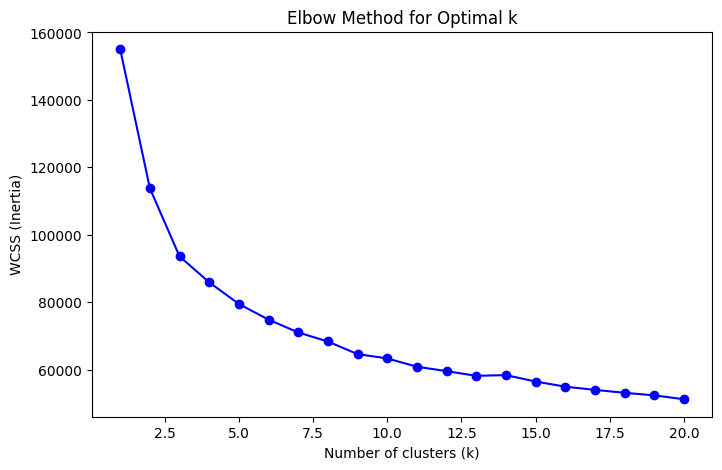

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_majority = X_data[y_data==0]  # mayoritas saja

wcss = []
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_majority)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()


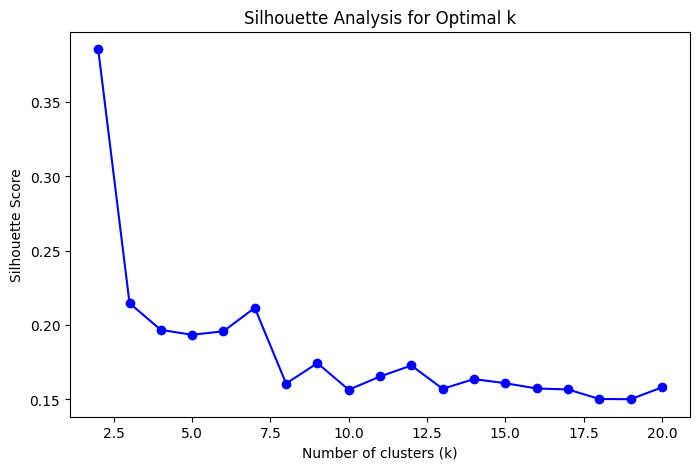

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 21):  # silhouette tidak bisa dihitung untuk k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_majority)
    score = silhouette_score(X_majority, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,21), sil_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()


In [ ]:
scale_pos_weight = len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])

model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=scale_pos_weight)
model.fit(X_resampled, y_resampled)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:36:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test_processed_no_y)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.99      0.80      0.89      8529
           1       0.05      0.60      0.09       149

    accuracy                           0.80      8678
   macro avg       0.52      0.70      0.49      8678
weighted avg       0.98      0.80      0.87      8678

[[6855 1674]
 [  60   89]]


# Condensed Nearest Neighbours

In [ ]:
# VERY aggresive undersampling

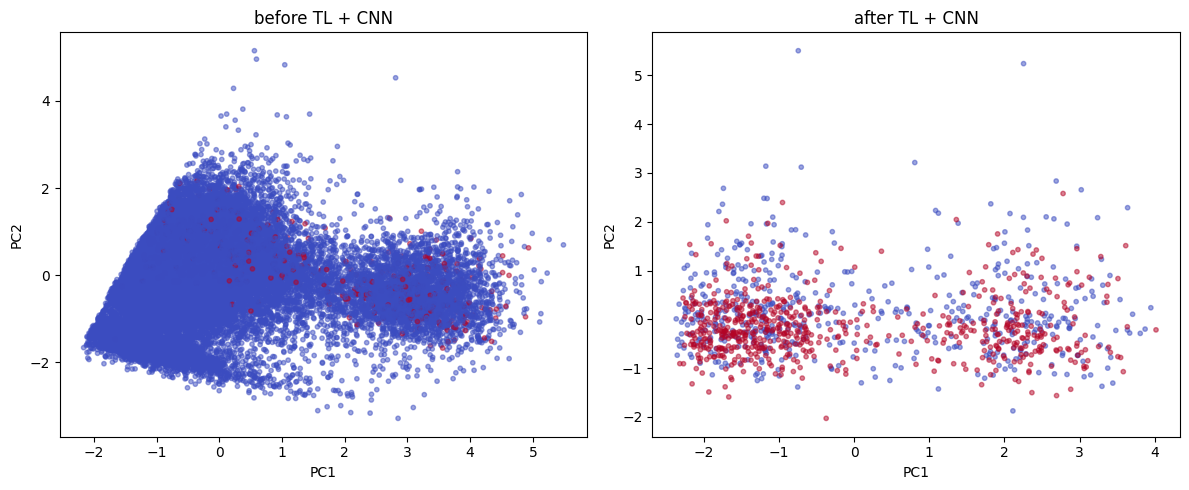

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from imblearn.under_sampling import TomekLinks, CondensedNearestNeighbour
from sklearn.decomposition import PCA


tl = TomekLinks(sampling_strategy='majority')
X_tl, y_tl = tl.fit_resample(X_train_processed, y_train)


cnn = CondensedNearestNeighbour(sampling_strategy='majority')
X_resampled, y_resampled = cnn.fit_resample(X_tl, y_tl)


pca = PCA(n_components=2)
X_pca_before = pca.fit_transform(X_train_processed)
X_pca_after = pca.fit_transform(X_resampled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca_before[:,0], X_pca_before[:,1], c=y_train, cmap='coolwarm', alpha=0.5, s=10)
plt.title("before TL + CNN")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1,2,2)
plt.scatter(X_pca_after[:,0], X_pca_after[:,1], c=y_resampled, cmap='coolwarm', alpha=0.5, s=10)
plt.title("after TL + CNN")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


In [ ]:
#               precision    recall  f1-score   support

#            0       0.99      0.65      0.78      8529
#            1       0.03      0.61      0.06       149

#     accuracy                           0.64      8678
#    macro avg       0.51      0.63      0.42      8678
# weighted avg       0.97      0.64      0.77      8678


# [[5502 3027]
#  [  58   91]]
# THIS IS THE OUTPUT FOR CNN + TOMEK LINKS(NOT GREAT)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_2d_space_clusters(X_2d, y, clusters=None, title=''):
    plt.figure(figsize=(8,6))


    plt.scatter(X_2d[y==1,0], X_2d[y==1,1], alpha=0.5, label='Minority', color='red')


    if clusters is not None:
        n_clusters = len(np.unique(clusters))
        colors = plt.cm.get_cmap('tab10', n_clusters)  # colormap
        for c in range(n_clusters):
            idx = np.where((y==0) & (clusters==c))
            plt.scatter(X_2d[idx,0], X_2d[idx,1], alpha=0.5, color=colors(c), label=f'Majority cluster {c}')
    else:
        plt.scatter(X_2d[y==0,0], X_2d[y==0,1], alpha=0.2, label='Majority', color='blue')

    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()


/tmp/ipython-input-2885410709.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_clusters)  # colormap


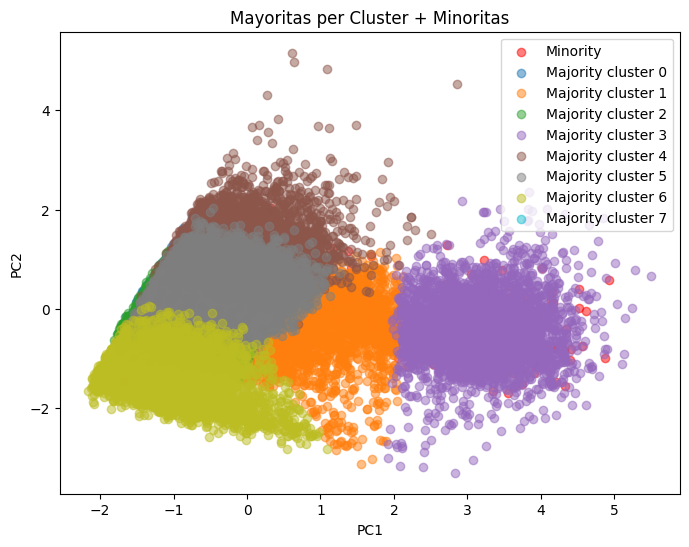

In [ ]:

from sklearn.decomposition import PCA

X_combined = pd.concat([X_majority, X_minority])
y_combined = pd.concat([y_majority, y_minority])


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)


plot_2d_space_clusters(X_pca, y_combined, clusters=np.concatenate([clusters, [-1]*len(y_minority)]),
                       title='Mayoritas per Cluster + Minoritas')


In [ ]:




model = LogisticRegression()
model.fit(X_train_processed_no_y, y_train)

# scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)
# model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=scale_pos_weight)
# model.fit(X_train_processed_no_y, y_train)

# Predict probability
y_proba = model.predict_proba(X_test_processed_no_y)[:, 1]  # prob kelas minoritas (stroke=1)

# Atur threshold
threshold = 0.029658
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluasi
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred_custom, digits=3))
cm = confusion_matrix(y_test, y_pred_custom)
print(cm)


ROC-AUC: 0.8349830542617726
              precision    recall  f1-score   support

           0      0.993     0.822     0.899      8529
           1      0.062     0.671     0.113       149

    accuracy                          0.819      8678
   macro avg      0.527     0.747     0.506      8678
weighted avg      0.977     0.819     0.886      8678

[[7011 1518]
 [  49  100]]


In [ ]:
# ROC-AUC: 0.7845888602722177
#               precision    recall  f1-score   support

#            0      0.995     0.640     0.779      8529
#            1      0.038     0.812     0.072       149

#     accuracy                          0.643      8678
#    macro avg      0.516     0.726     0.426      8678
# weighted avg      0.978     0.643     0.767      8678

# [[5458 3071]
#  [  28  121]]

xgb

In [ ]:
proba_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba_class1": y_proba
})

proba_df.head(10)

,y_true,y_proba_class1
0,0,0.001956
1,0,0.004712
2,0,0.061625
3,0,0.029033
4,0,0.039304
5,0,0.000503
6,0,0.114895
7,0,0.004957
8,0,0.117483
9,0,0.022096


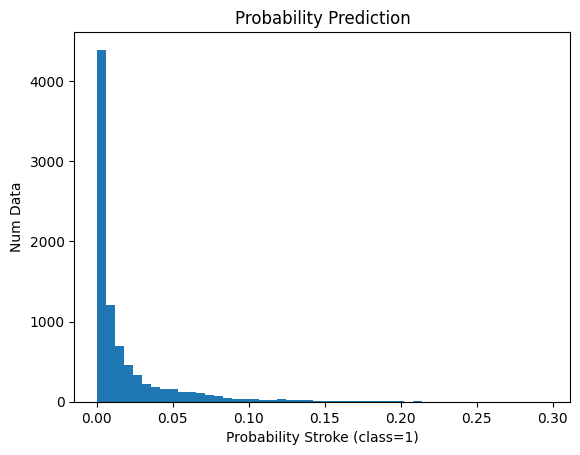

In [ ]:
import matplotlib.pyplot as plt

plt.hist(proba_df["y_proba_class1"], bins=50)
plt.xlabel("Probability Stroke (class=1)")
plt.ylabel("Num Data")
plt.title("Probability Prediction")
plt.show()


In [ ]:
proba_df.describe()

,y_true,y_proba_class1
count,8678.000000,8678.000000
mean,0.017170,0.018236
std,0.129911,0.029658
min,0.000000,0.000236
25%,0.000000,0.001578
50%,0.000000,0.006009
75%,0.000000,0.020784
max,1.000000,0.296671


In [ ]:
#Threshold = 0.029658 has the best f1 score

In [ ]:
from sklearn.metrics import classification_report

for t in [0.018236, 0.029658, 0.000236, 0.001578, 0.006009, 0.020784, 0.296671]:
    y_pred_custom = (proba_df["y_proba_class1"] >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(proba_df["y_true"], y_pred_custom, digits=3))
    cm = confusion_matrix(proba_df["y_true"], y_pred_custom)
    print(cm)



Threshold = 0.018236
              precision    recall  f1-score   support

           0      0.995     0.736     0.846      8529
           1      0.050     0.799     0.095       149

    accuracy                          0.737      8678
   macro avg      0.523     0.767     0.470      8678
weighted avg      0.979     0.737     0.833      8678

[[6279 2250]
 [  30  119]]

Threshold = 0.029658
              precision    recall  f1-score   support

           0      0.993     0.822     0.899      8529
           1      0.062     0.671     0.113       149

    accuracy                          0.819      8678
   macro avg      0.527     0.747     0.506      8678
weighted avg      0.977     0.819     0.886      8678

[[7011 1518]
 [  49  100]]

Threshold = 0.000236
              precision    recall  f1-score   support

           0      1.000     0.000     0.000      8529
           1      0.017     1.000     0.034       149

    accuracy                          0.017      8678
   macro

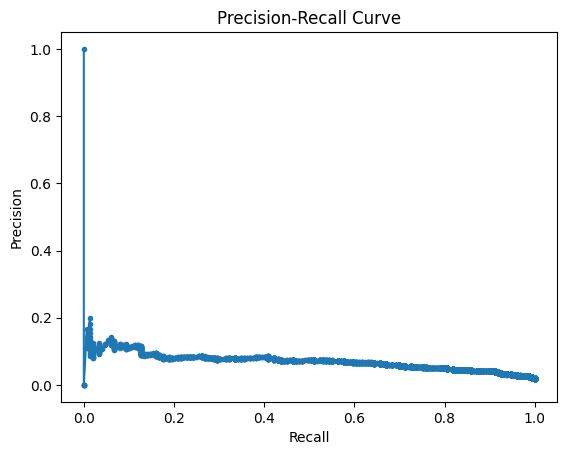

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(proba_df["y_true"], proba_df["y_proba_class1"])

plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [ ]:
# https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets#t9